<a href="https://colab.research.google.com/github/Priyalapotlapati/Project/blob/main/Disease_Diagnosis_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Download the Dataset](https://drive.google.com/file/d/1LEajTKnTgKGtnWmNHHdQuaJ-j4O7zU_J/view?usp=sharing)

In [ ]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Diabetes dataset (replace with actual path if needed)
url = '/content/diabetes.csv'
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age', 'Outcome']
data = pd.read_csv(url, names=column_names)

# Display first few rows of the dataset
print(data.head())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())



# Descriptive statistics of the dataset
print("\nDescriptive Statistics:")
print(data.describe())


            Pregnancies        Glucose  BloodPressure SkinThickness Insulin  \
Pregnancies     Glucose  BloodPressure  SkinThickness       Insulin     BMI   
6                   148             72             35             0    33.6   
1                    85             66             29             0    26.6   
8                   183             64              0             0    23.3   
1                    89             66             23            94    28.1   

                                  BMI  Age  Outcome  
Pregnancies  DiabetesPedigreeFunction  Age  Outcome  
6                               0.627   50        1  
1                               0.351   31        0  
8                               0.672   32        1  
1                               0.167   21        0  

Missing Values:
Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Age              0
Outcome          0
dtype: int64

Descriptive Statis

##**Data Preprocessing**

###**1. Data Cleaning**

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Load the dataset
data = pd.read_csv('/content/diabetes.csv')

# Handle missing values - using median for numerical features
numerical_cols = ['Age']  # Example numerical columns
imputer = SimpleImputer(strategy='median')
data[numerical_cols] = imputer.fit_transform(data[numerical_cols])

# Handle missing categorical values - using mode for categorical features
categorical_cols = ['Glucose', 'Insulin']  # Example categorical columns
imputer = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = imputer.fit_transform(data[categorical_cols])

# Remove duplicates
data = data.drop_duplicates()


# Display cleaned data
print(data.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction   Age  Outcome  
0                     0.627  50.0        1  
1                     0.351  31.0        0  
2                     0.672  32.0        1  
3                     0.167  21.0        0  
4                     2.288  33.0        1  


###**2. Feature Engineering**




In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Example of one-hot encoding categorical variables
categorical_cols = ['Insulin', 'Glucose', 'Age']
encoder = OneHotEncoder(drop='first')  # Drop first to avoid multicollinearity
encoded_data = encoder.fit_transform(data[categorical_cols])

# Example of scaling numerical features
numerical_cols = ['Age', 'BloodPressure', 'Pregnancies']  # Example numerical columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[numerical_cols])


# Display engineered features
print(data[['Age', 'BloodPressure', 'BMI']].head())


    Age  BloodPressure   BMI
0  50.0             72  33.6
1  31.0             66  26.6
2  32.0             64  23.3
3  21.0             66  28.1
4  33.0             40  43.1


##**Exploratory Data Analysis (EDA)**


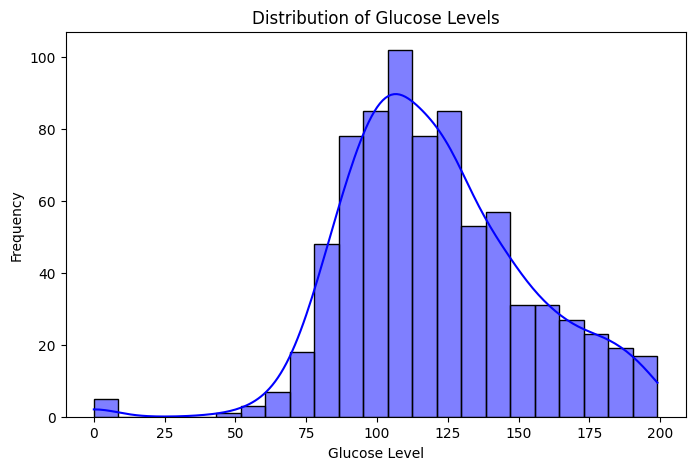

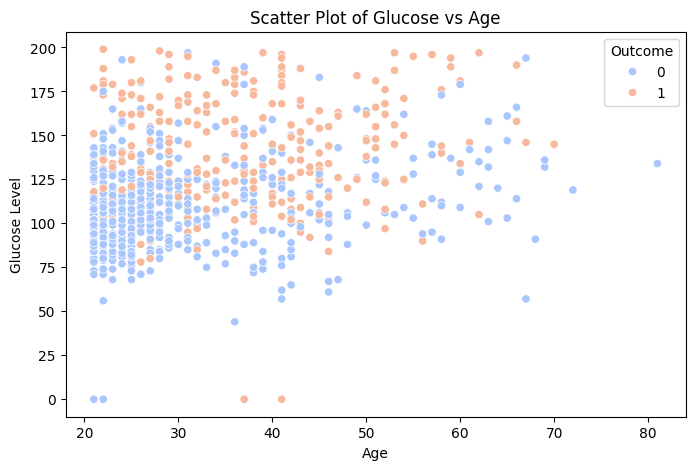

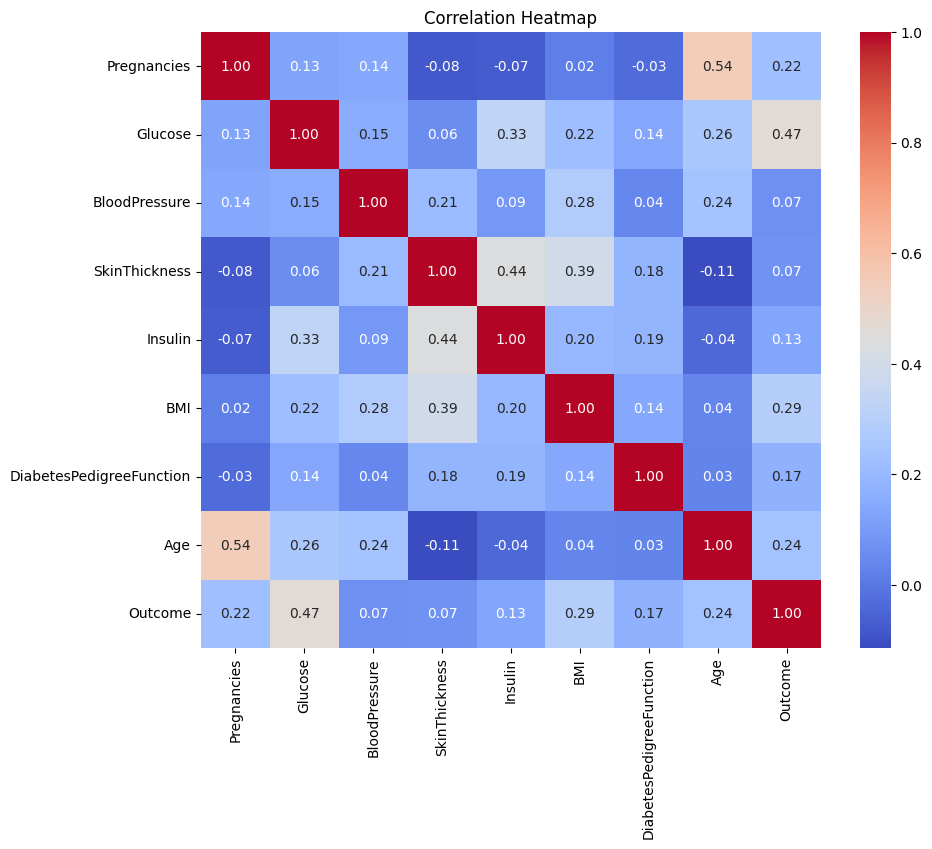

<ipython-input-13-5dab58bc9efa>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Outcome', palette='Set2')


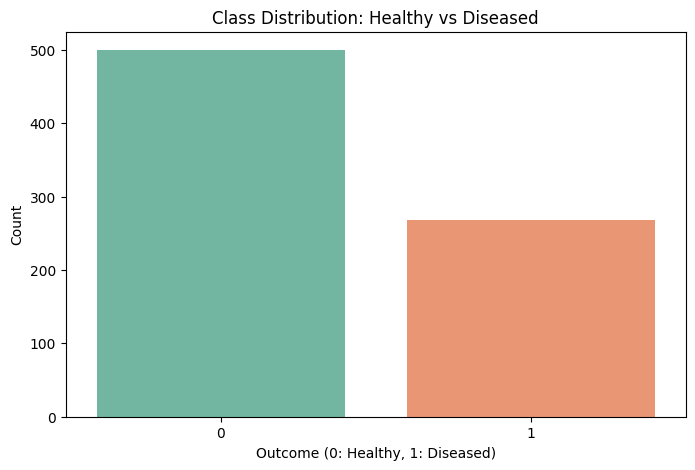

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace 'diabetes.csv' with the actual dataset path)
data = pd.read_csv('/content/diabetes.csv')

# Histogram: Distribution of a numerical variable (e.g., Glucose)
plt.figure(figsize=(8, 5))
sns.histplot(data['Glucose'], kde=True, color='blue')
plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')
plt.show()

# Scatter Plot: Relationship between Glucose and Age
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='Age', y='Glucose', hue='Outcome', palette='coolwarm')
plt.title('Scatter Plot of Glucose vs Age')
plt.xlabel('Age')
plt.ylabel('Glucose Level')
plt.show()

# Heatmap: Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Count Plot: Class imbalance
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Outcome', palette='Set2')
plt.title('Class Distribution: Healthy vs Diseased')
plt.xlabel('Outcome (0: Healthy, 1: Diseased)')
plt.ylabel('Count')
plt.show()


###**2. Statistical Insights**


In [ ]:
from scipy.stats import ttest_ind, chi2_contingency

# t-test: Glucose levels for healthy vs diseased patients
healthy = data[data['Outcome'] == 0]['Glucose']
diseased = data[data['Outcome'] == 1]['Glucose']
t_stat, p_value = ttest_ind(healthy, diseased)

print(f"T-Test Results for Glucose Levels:")
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Significant difference between healthy and diseased groups.")
else:
    print("No significant difference between healthy and diseased groups.")

# Chi-Squared Test: Relationship between Age and Outcome
contingency_table = pd.crosstab(data['Age'], data['Outcome'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Squared Test Results:")
print(f"Chi-squared Statistic: {chi2:.2f}, P-value: {p:.4f}")
if p < 0.05:
    print("Significant relationship between Age and Outcome.")
else:
    print("No significant relationship between Age and Outcome.")


T-Test Results for Glucose Levels:
T-statistic: -14.60, P-value: 0.0000
Significant difference between healthy and diseased groups.

Chi-Squared Test Results:
Chi-squared Statistic: 140.94, P-value: 0.0000
Significant relationship between Age and Outcome.


##**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Load dataset
data = pd.read_csv('/content/diabetes.csv')

# Assume 'Disease' is the target variable and others are features
X = data.drop(columns=['Glucose'])  # Features
y = data['Glucose']  # Target

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Set Shape:", X_train.shape, y_train.shape)
print("Testing Set Shape:", X_test.shape, y_test.shape)


Training Set Shape: (614, 8) (614,)
Testing Set Shape: (154, 8) (154,)


###**2. Use Stratified Sampling for Imbalanced Datasets**


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Generate synthetic diseases dataset
# Assume 3 classes for diseases
X, y = make_classification(
    n_samples=200,
    n_features=10,
    n_informative=5,
    n_classes=3,
    weights=[0.5, 0.3, 0.2],  # Imbalance between classes
    random_state=42
)

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=[f"Feature_{i+1}" for i in range(X.shape[1])])
df['Disease'] = y  # Add target column

# Display class distribution in original dataset
print("Original Class Distribution:\n", df['Disease'].value_counts(normalize=True))

# Perform stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns='Disease'),  # Features
    df['Disease'],              # Target
    test_size=0.2,              # 80% train, 20% test
    random_state=42,
    stratify=df['Disease']      # Ensure stratification
)

# Display class distributions in train and test sets
print("\nTraining Set Class Distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting Set Class Distribution:\n", y_test.value_counts(normalize=True))


Original Class Distribution:
 Disease
0    0.5
1    0.3
2    0.2
Name: proportion, dtype: float64

Training Set Class Distribution:
 Disease
0    0.5
1    0.3
2    0.2
Name: proportion, dtype: float64

Testing Set Class Distribution:
 Disease
0    0.5
1    0.3
2    0.2
Name: proportion, dtype: float64


###**3. Visualizing the Split**


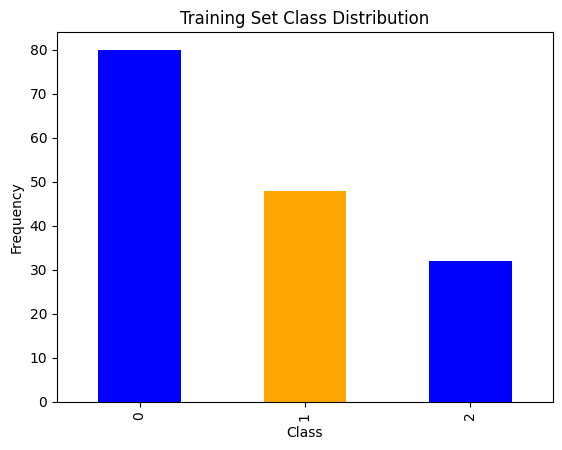

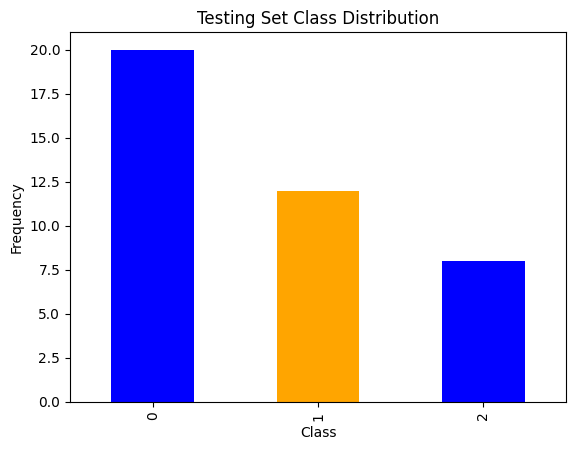

In [ ]:
import matplotlib.pyplot as plt

# Visualize class distribution
def plot_class_distribution(y_data, title):
    y_data.value_counts().plot(kind='bar', color=['blue', 'orange'])
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Frequency")
    plt.show()

# Plot for training and testing sets
plot_class_distribution(y_train, "Training Set Class Distribution")
plot_class_distribution(y_test, "Testing Set Class Distribution")


##**Model Selection**

###**3. Implementation Examples**


####**Logistic Regression Implementation**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Split data into features (X) and target (y)
X = data.drop(columns=['Glucose'])  # Assuming 'Glucose' is the target column
y = data['Glucose']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = log_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.006493506493506494
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
          57       0.00      0.00      0.00         0
          62       0.00      0.00      0.00         1
          68       0.00      0.00      0.00         1
          71       0.00      0.00      0.00         1
          73       0.00      0.00      0.00         1
          74       0.00      0.00      0.00         3
          75       0.00      0.00      0.00         1
          77       0.00      0.00      0.00         1
          78       0.00      0.00      0.00         1
          79       0.00      0.00      0.00         0
          80       0.00      0.00      0.00         2
          81       0.00      0.00      0.00         1
          83       0.00      0.00      0.00         2
          84       0.00      0.00      0.00         3
          85       0.00      0.00      0.00         2
          86       0.00   

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

####**Decision Tree Implementation**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.025974025974025976
Classification Report:
               precision    recall  f1-score   support

          62       0.00      0.00      0.00         1
          68       0.00      0.00      0.00         1
          71       0.00      0.00      0.00         1
          73       0.00      0.00      0.00         1
          74       0.00      0.00      0.00         3
          75       0.00      0.00      0.00         1
          77       0.00      0.00      0.00         1
          78       0.00      0.00      0.00         1
          80       0.00      0.00      0.00         2
          81       0.00      0.00      0.00         1
          83       0.00      0.00      0.00         2
          84       0.00      0.00      0.00         3
          85       0.00      0.00      0.00         2
          86       0.00      0.00      0.00         1
          87       0.00      0.00      0.00         1
          88       0.00      0.00      0.00         2
          89       0.00   

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

####**Random Forest Implementation**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.006493506493506494
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
          57       0.00      0.00      0.00         0
          62       0.00      0.00      0.00         1
          65       0.00      0.00      0.00         0
          68       0.00      0.00      0.00         1
          71       0.00      0.00      0.00         1
          73       0.00      0.00      0.00         1
          74       0.00      0.00      0.00         3
          75       0.00      0.00      0.00         1
          77       0.00      0.00      0.00         1
          78       0.00      0.00      0.00         1
          79       0.00      0.00      0.00         0
          80       0.00      0.00      0.00         2
          81       0.00      0.00      0.00         1
          83       0.00      0.00      0.00         2
          84       0.00      0.00      0.00         3
          85       0.00   

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

####**SVM Implementation**

In [ ]:
from sklearn.svm import SVC

# SVM Model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.006493506493506494
Classification Report:
               precision    recall  f1-score   support

          62       0.00      0.00      0.00         1
          68       0.00      0.00      0.00         1
          71       0.00      0.00      0.00         1
          73       0.00      0.00      0.00         1
          74       0.00      0.00      0.00         3
          75       0.00      0.00      0.00         1
          77       0.00      0.00      0.00         1
          78       0.00      0.00      0.00         1
          80       0.00      0.00      0.00         2
          81       0.00      0.00      0.00         1
          83       0.00      0.00      0.00         2
          84       0.00      0.00      0.00         3
          85       0.00      0.00      0.00         2
          86       0.00      0.00      0.00         1
          87       0.00      0.00      0.00         1
          88       0.00      0.00      0.00         2
          89       0.00   

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

####**ANN Implementation (Using TensorFlow/Keras)**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ANN Model
ann_model = Sequential([
    Dense(32, activation='relu', input_dim=X_train.shape[1]),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
ann_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = ann_model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0000e+00 - loss: -3573.4297 - val_accuracy: 0.0000e+00 - val_loss: -7489.8057
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -9141.9072 - val_accuracy: 0.0000e+00 - val_loss: -13459.4482
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -15706.3428 - val_accuracy: 0.0000e+00 - val_loss: -21386.2285
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -25920.0410 - val_accuracy: 0.0000e+00 - val_loss: -32266.3652
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -37566.4883 - val_accuracy: 0.0000e+00 - val_loss: -47559.2070
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -54693.8828 - val_accuracy: 0.0000e+00 - val_loss: -67632.1562
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -80428.2031 - val_accuracy: 0.0000e+00 - val_loss: -94055.1875
Epoch

####**Choosing the Best Algorithm**


##**Model Training**

###**1. Cross-Validation**


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_diabetes

# Load example dataset
data = load_diabetes()
X, y = data.data, data.target

# Initialize a Random Forest classifier
clf = RandomForestClassifier(random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

# Display results
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.2f}")


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Cross-Validation Scores: [0.         0.01123596 0.02272727 0.         0.        ]
Mean CV Score: 0.01


###**2. Hyperparameter Tuning**


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

# Load the diabetes dataset (replace 'diabetes.csv' with your file path)
diabetes_data = pd.read_csv('/content/diabetes.csv')

# Define features (X) and target (y)
X = diabetes_data.drop(columns=['Glucose'])  # Assuming 'Glucose' is the target column
y = diabetes_data['Glucose']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Random Forest classifier (clf)
clf = RandomForestClassifier(random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize the GridSearchCV
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Display the best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.2f}")


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
Best CV Score: 0.03


**(b) RandomizedSearchCV**


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define random parameter distributions
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 20)
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=clf, param_distributions=param_dist,
                                   n_iter=10, cv=5, scoring='accuracy', random_state=42)

# Fit the model
random_search.fit(X, y)

# Display the best parameters and score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.2f}")


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'max_depth': 30, 'min_samples_split': 8, 'n_estimators': 171}
Best CV Score: 0.02


###**3. Handling Class Imbalance**


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from collections import Counter

# Generate an imbalanced synthetic dataset
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    n_classes=2,
    weights=[0.9, 0.1],  # 90% majority, 10% minority
    random_state=42
)

# Check original class distribution
print("Original Class Distribution:", Counter(y))

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Check resampled class distribution
print("Resampled Class Distribution:", Counter(y_resampled))


Original Class Distribution: Counter({0: 448, 1: 52})
Resampled Class Distribution: Counter({0: 359, 1: 359})


In [ ]:
# Initialize Random Forest with class weights
clf_weighted = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train and evaluate the model
clf_weighted.fit(X_train, y_train)
weighted_score = clf_weighted.score(X_test, y_test)
print(f"Weighted Classifier Accuracy: {weighted_score:.2f}")


Weighted Classifier Accuracy: 0.94


##**Model Evaluation**

Training Accuracy: 1.00
Test Accuracy: 0.76
Precision: 0.68
Recall: 0.59
F1-Score: 0.63
AUC-ROC: 0.81


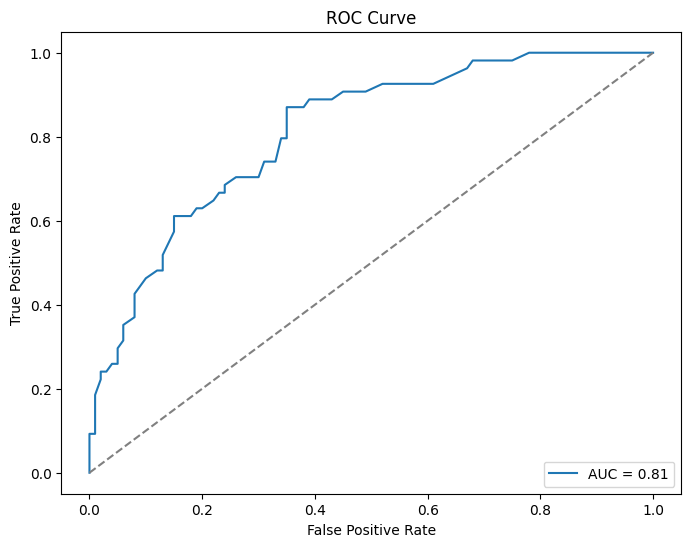

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('/content/diabetes.csv')

# Separate features and target variable
X = data.drop('Outcome', axis=1)  # Features
y = data['Outcome']  # Target variable (e.g., 0 for healthy, 1 for diseased)

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for AUC-ROC

# Evaluate on training data
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2f}")

# Evaluate on testing data
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_prob)

print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"AUC-ROC: {roc_auc:.2f}")

# Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


##**Interpreting Results**

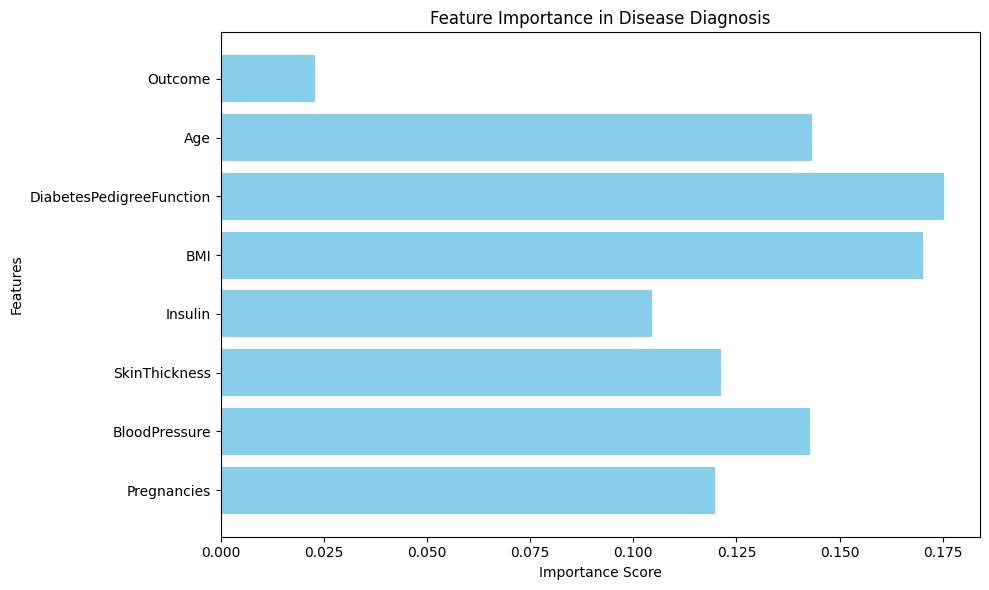

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the dataset
# Replace 'path_to_file.csv' with the actual path to your dataset
try:
    diabetes_data = pd.read_csv('/content/diabetes.csv')
except FileNotFoundError:
    raise FileNotFoundError("Ensure the dataset file exists at the specified path.")

# Ensure 'Glucose' column exists in the dataset
if 'Glucose' not in diabetes_data.columns:
    raise ValueError("The dataset does not contain the required 'Glucose' column.")

# Features and target
X = diabetes_data.drop(columns=['Glucose'])  # Features
y = diabetes_data['Glucose']  # Target

# Example: If the 'Glucose' column needs categorization
# y = pd.cut(diabetes_data['Glucose'], bins=[0, 140, 200], labels=[0, 1])

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Extract feature importance
feature_importance = model.feature_importances_
features = X.columns

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance in Disease Diagnosis')
plt.tight_layout()
plt.show()


**For Logistic Regression**

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


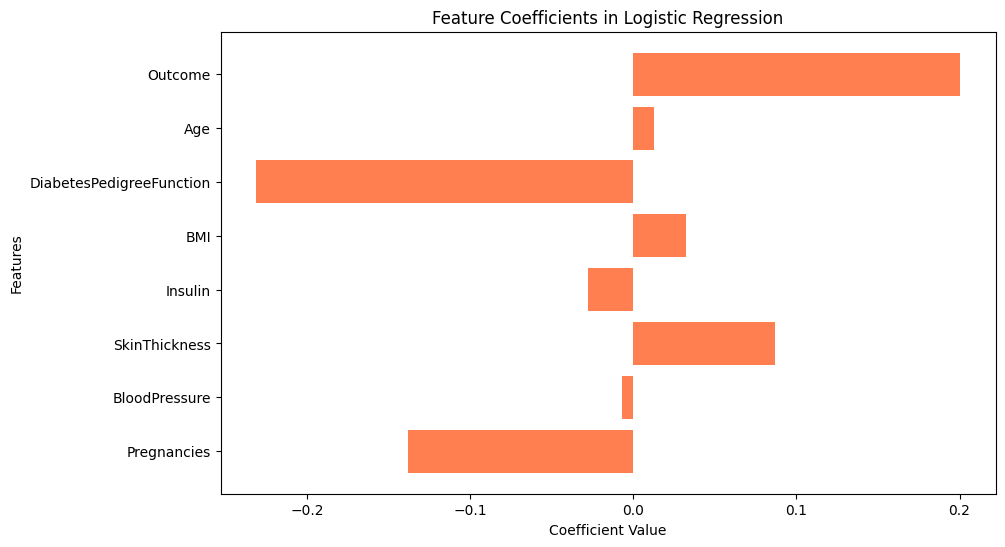

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Train a Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X, y)

# Extract feature coefficients
coefficients = log_reg.coef_[0]
features = X.columns

# Plot feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(features, coefficients, color='coral')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.title('Feature Coefficients in Logistic Regression')
plt.show()


###**2. Error Analysis**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Make predictions
y_pred = model.predict(X)

# Compute the confusion matrix
cm = confusion_matrix(y, y_pred)

# Display the classification report
print("Classification Report:")
print(classification_report(y, y_pred))

# Analyze misclassified cases
misclassified_indices = np.where(y != y_pred)[0]
misclassified_cases = diabetes_data.iloc[misclassified_indices]

print("Misclassified Cases:")
print(misclassified_cases.head())



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
          44       1.00      1.00      1.00         1
          56       1.00      1.00      1.00         1
          57       1.00      1.00      1.00         2
          61       1.00      1.00      1.00         1
          62       1.00      1.00      1.00         1
          65       1.00      1.00      1.00         1
          67       1.00      1.00      1.00         1
          68       1.00      1.00      1.00         3
          71       1.00      1.00      1.00         4
          72       1.00      1.00      1.00         1
          73       1.00      1.00      1.00         3
          74       1.00      1.00      1.00         4
          75       1.00      1.00      1.00         2
          76       1.00      1.00      1.00         2
          77       1.00      1.00      1.00         2
          78       1.00      1.00      1.00         4
    

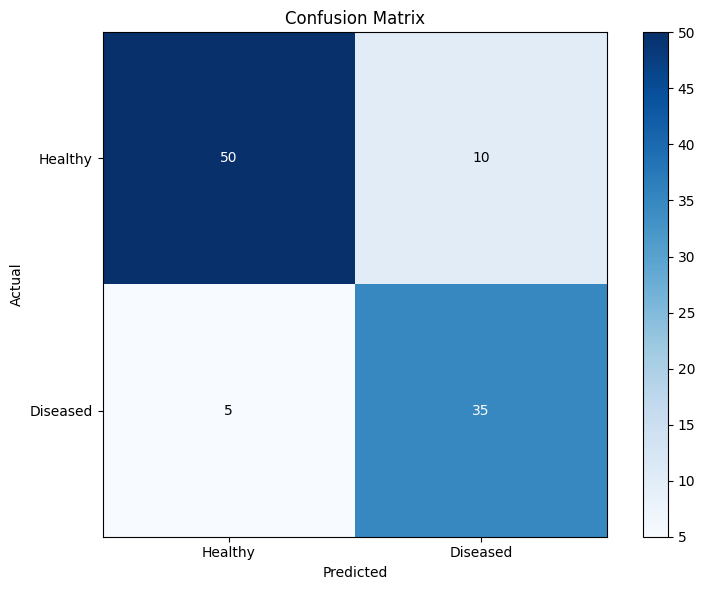

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example confusion matrix
cm = np.array([[50, 10], [5, 35]])  # Replace with your confusion matrix
labels = ['Healthy', 'Diseased']  # Replace with your class labels

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()

# Add labels, title, and ticks
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

# Annotate each cell with the numeric value
threshold = cm.max() / 2  # Set threshold for text color
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, f'{cm[i, j]}',  # Cell value
            ha='center', va='center',  # Align center
            color='white' if cm[i, j] > threshold else 'black'  # Text color
        )

plt.tight_layout()
plt.show()


##**Deployment Preparation**

###**1. Model Export**

In [ ]:
import pandas as pd
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load the dataset (replace 'diabetes.csv' with your actual dataset path)
diabetes_data = pd.read_csv("/content/diabetes.csv")

# Check if 'Glucose' column exists
if 'Glucose' not in diabetes_data.columns:
    raise KeyError("The column 'Glucose' is not present in the dataset.")

# Split data into features (X) and target (y)
X = diabetes_data.drop(columns=['Glucose'])
y = diabetes_data['Glucose']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Save the model using pickle
with open('diabetes_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved as 'diabetes_model.pkl'")


Model saved as 'diabetes_model.pkl'


###**2. API Creation**

In [ ]:
from flask import Flask, request, jsonify
import pickle

# Load the trained model
with open('diabetes_model.pkl', 'rb') as file:
    model = pickle.load(file)

# Initialize Flask app
app = Flask(__name__)

# Define a route for prediction
@app.route('/predict', methods=['POST'])
def predict():
    # Get data from the request
    input_data = request.json
    features = [input_data['Pregnancies'], input_data['Glucose'], input_data['BloodPressure'],
                input_data['SkinThickness'], input_data['Insulin'], input_data['BMI'],
                input_data['DiabetesPedigreeFunction'], input_data['Age']]

    # Make a prediction
    prediction = model.predict([features])[0]
    probability = model.predict_proba([features])[0][1]

    # Return the result
    return jsonify({'Prediction': 'Diabetic' if prediction == 1 else 'Non-Diabetic',
                    'Probability': probability})

# Run the app
if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with stat


###**3. Integration**


In [ ]:
pip install streamlit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.7 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import requests

# Define the Streamlit app
st.title("Diabetes Diagnosis System")

# Input fields for user data
pregnancies = st.number_input("Pregnancies", 0, 20)
glucose = st.number_input("Glucose Level", 0, 200)
blood_pressure = st.number_input("Blood Pressure", 0, 120)
skin_thickness = st.number_input("Skin Thickness", 0, 100)
insulin = st.number_input("Insulin Level", 0, 900)
bmi = st.number_input("BMI", 0.0, 50.0)
pedigree = st.number_input("Diabetes Pedigree Function", 0.0, 2.5)
age = st.number_input("Age", 0, 120)

# Button to send data to the API
if st.button("Predict"):
    # API URL
    api_url = "http://127.0.0.1:5000/predict"
    input_data = {
        'Pregnancies': pregnancies,
        'Glucose': glucose,
        'BloodPressure': blood_pressure,
        'SkinThickness': skin_thickness,
        'Insulin': insulin,
        'BMI': bmi,
        'DiabetesPedigreeFunction': pedigree,
        'Age': age
    }

    # Send request to API
    response = requests.post(api_url, json=input_data)
    result = response.json()

    # Display prediction
    st.write(f"Prediction: {result['Prediction']}")
    st.write(f"Probability: {result['Probability']:.2f}")


2024-11-26 10:20:30.759 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-26 10:20:30.845 
  command:

    streamlit run /usr/local/lib/python3.10/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2024-11-26 10:20:30.847 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-26 10:20:30.850 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-26 10:20:30.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-26 10:20:30.855 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-26 10:20:30.857 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-26 10:20:30.860 Session state does not 

##**Deployment**

###**1. Cloud Hosting**

In [ ]:
pip install fastapi uvicorn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 5.0 MB/s eta 0:00:00


In [ ]:
from fastapi import FastAPI
import pickle
import pandas as pd

# Load the trained model
model = pickle.load(open('diabetes_model.pkl', 'rb'))

# Initialize the API
app = FastAPI()

# Define a prediction endpoint
@app.post("/predict")
def predict(features: dict):
    df = pd.DataFrame([features])  # Convert input to DataFrame
    prediction = model.predict(df)
    return {"prediction": int(prediction[0])}


###**2. Monitoring**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Load the existing and new data
existing_data = pd.read_csv('/content/diabetes.csv')
new_data = pd.read_csv('/content/diabetes.csv')

# Combine old and new data
updated_data = pd.concat([existing_data, new_data], axis=0)

# Separate features and target variable
X = updated_data.drop(columns=['Outcome'])  # Features
y = updated_data['Outcome']  # Target variable

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate on the test set
y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))


Model Accuracy: 0.9545454545454546


**2. Monitoring Data Drift**
- Detect whether the distribution of new input data is significantly different from the training data.

**Code Example:**

In [ ]:
from scipy.stats import ks_2samp

# Compare the distribution of a feature in old vs. new data
for column in X.columns:
    stat, p_value = ks_2samp(existing_data[column], new_data[column])
    print(f"Feature: {column}, P-value: {p_value}")
    if p_value < 0.05:
        print(f"Warning: Data drift detected in feature '{column}'!")


Feature: Pregnancies, P-value: 1.0
Feature: Glucose, P-value: 1.0
Feature: BloodPressure, P-value: 1.0
Feature: SkinThickness, P-value: 1.0
Feature: Insulin, P-value: 1.0
Feature: BMI, P-value: 1.0
Feature: DiabetesPedigreeFunction, P-value: 1.0
Feature: Age, P-value: 1.0


###**Visualization for Maintenance**


- Model Accuracy Over Time Monitor how accuracy or other metrics change after periodic retraining.

**Code Example for Visualization:**

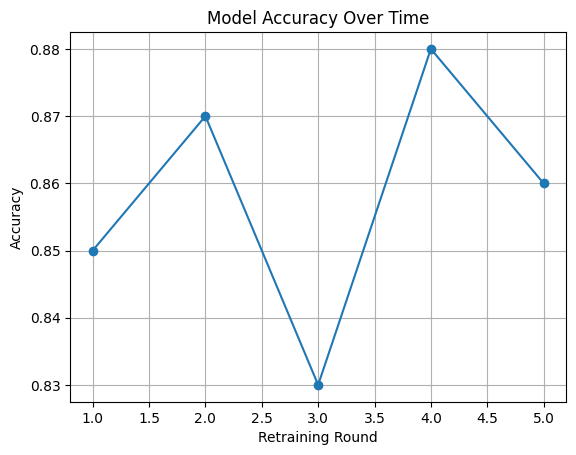

In [ ]:
import matplotlib.pyplot as plt

# Simulated accuracy values
accuracy_scores = [0.85, 0.87, 0.83, 0.88, 0.86]
retraining_rounds = [1, 2, 3, 4, 5]

# Plot the accuracy trend
plt.plot(retraining_rounds, accuracy_scores, marker='o')
plt.title("Model Accuracy Over Time")
plt.xlabel("Retraining Round")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


- Data Drift Visualization Plot distributions of a feature over time to visualize data drift.

**Code Example:**

<ipython-input-35-92b5ddd6d651>:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(existing_data['Age'], label='Existing Data', shade=True)
<ipython-input-35-92b5ddd6d651>:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(new_data['Age'], label='New Data', shade=True)


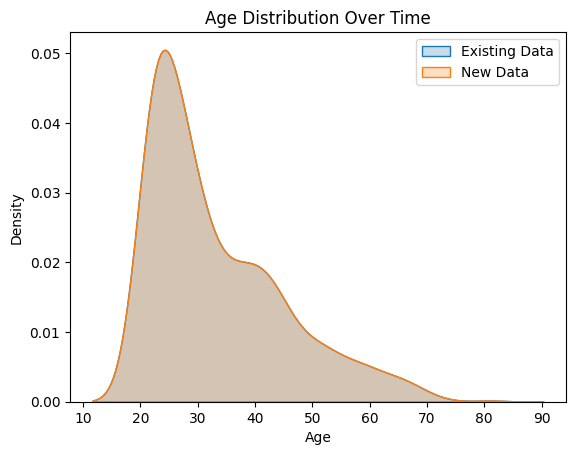

In [ ]:
import seaborn as sns

# Compare distributions of a feature
sns.kdeplot(existing_data['Age'], label='Existing Data', shade=True)
sns.kdeplot(new_data['Age'], label='New Data', shade=True)
plt.title("Age Distribution Over Time")
plt.legend()
plt.show()
